# ⚾ MLB Pitch Bot – Model Prototype v2.1

This notebook explores the highly-accurate **Pitch Family** model enhanced with **Handedness** and **Base State**.

## 🧠 Modeling Philosophy
1. **Family Target**: Predict Fastball, Breaking, Offspeed.
2. **Advanced Context**: Added Pitcher/Batter Handedness and Men On Base state.
3. **No Leaky Features**: Avoiding velocity/spin.

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import xgboost as xgb
import seaborn as sns
import matplotlib.pyplot as plt

# Project root for src imports
ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))

from src.database import query_all_pitches
from src.dataset_generator import add_features
from src.constants import DATABASE_PATH
from src.features import _classify_pitch_family

## 1. Data Ingestion
Load raw pitches with new features.

In [2]:
df_raw = query_all_pitches()
print(f"Loaded {len(df_raw)} pitches.")
df = add_features(df_raw)
df.head()

Loaded 115125 pitches.
    Adding situational features...


,at_bat_index,pitch_index,batter,pitcher,pitch_type,pitcher_hand,batter_side,men_on_base,call,velocity,...,count_1_0,count_1_1,count_1_2,count_2_0,count_2_1,count_2_2,count_3_0,count_3_1,count_3_2,is_leverage
0,0,3,Shohei Ohtani,Shota Imanaga,FF,L,L,Empty,Called Strike,92.5,...,0,0,0,0,0,0,0,0,0,0
1,0,4,Shohei Ohtani,Shota Imanaga,SL,L,L,Empty,Ball,83.1,...,0,1,0,0,0,0,0,0,0,0
2,0,5,Shohei Ohtani,Shota Imanaga,FF,L,L,Empty,"In play, out(s)",93.1,...,0,1,0,0,0,0,0,0,0,0
3,1,0,Tommy Edman,Shota Imanaga,FS,L,R,Empty,Ball,83.2,...,1,0,0,0,0,0,0,0,0,0
4,1,1,Tommy Edman,Shota Imanaga,FS,L,R,Empty,Swinging Strike,83.1,...,0,1,0,0,0,0,0,0,0,0


## 2. Advanced Feature Prep

In [3]:
df = df.dropna(subset=["pitch_type"]).copy()
df["pitch_family"] = df["pitch_type"].apply(_classify_pitch_family)

y_encoder = LabelEncoder()
y = y_encoder.fit_transform(df["pitch_family"])
class_names = y_encoder.classes_

# Advanced Categorical Features
p_le, b_le, m_le = LabelEncoder(), LabelEncoder(), LabelEncoder()
df["p_hand_enc"] = p_le.fit_transform(df["pitcher_hand"].fillna("R"))
df["b_side_enc"] = b_le.fit_transform(df["batter_side"].fillna("R"))
df["mob_enc"] = m_le.fit_transform(df["men_on_base"].fillna("Empty"))
df["prev_f_enc"] = LabelEncoder().fit_transform(df["prev_pitch_type_in_ab"].apply(_classify_pitch_family))

feat_cols = ["p_hand_enc", "b_side_enc", "mob_enc", "prev_f_enc", "inning", "balls", "strikes", "outs", "is_leverage"]
tendency_cols = [c for c in df.columns if "tendency_" in c and "_pct" in c]
X_cols = feat_cols + tendency_cols
X = df[X_cols].fillna(0)

print(f"Features used: {X_cols}")

Features used: ['p_hand_enc', 'b_side_enc', 'mob_enc', 'prev_f_enc', 'inning', 'balls', 'strikes', 'outs', 'is_leverage', 'tendency_count_CH_pct', 'tendency_count_CS_pct', 'tendency_count_CU_pct', 'tendency_count_EP_pct', 'tendency_count_FA_pct', 'tendency_count_FC_pct', 'tendency_count_FF_pct', 'tendency_count_FO_pct', 'tendency_count_FS_pct', 'tendency_count_FT_pct', 'tendency_count_KC_pct', 'tendency_count_KN_pct', 'tendency_count_SI_pct', 'tendency_count_SL_pct', 'tendency_count_ST_pct', 'tendency_count_SV_pct', 'tendency_global_CH_pct', 'tendency_global_CS_pct', 'tendency_global_CU_pct', 'tendency_global_EP_pct', 'tendency_global_FA_pct', 'tendency_global_FC_pct', 'tendency_global_FF_pct', 'tendency_global_FO_pct', 'tendency_global_FS_pct', 'tendency_global_FT_pct', 'tendency_global_KC_pct', 'tendency_global_KN_pct', 'tendency_global_SI_pct', 'tendency_global_SL_pct', 'tendency_global_ST_pct', 'tendency_global_SV_pct']


## 3. Training & Evaluation

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    eval_metric="mlogloss"
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=class_names))

              precision    recall  f1-score   support

    Breaking       0.59      0.35      0.43      4831
    Fastball       0.74      0.91      0.82     14141
    Offspeed       0.56      0.24      0.33      2165

    accuracy                           0.71     21137
   macro avg       0.63      0.50      0.53     21137
weighted avg       0.69      0.71      0.68     21137



## 4. Feature Importance

/var/folders/ly/37k3j5t12ns5zkrhzzc5bdxw0000gn/T/ipykernel_91938/1473055659.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_imp.values, y=feat_imp.index, palette="magma")


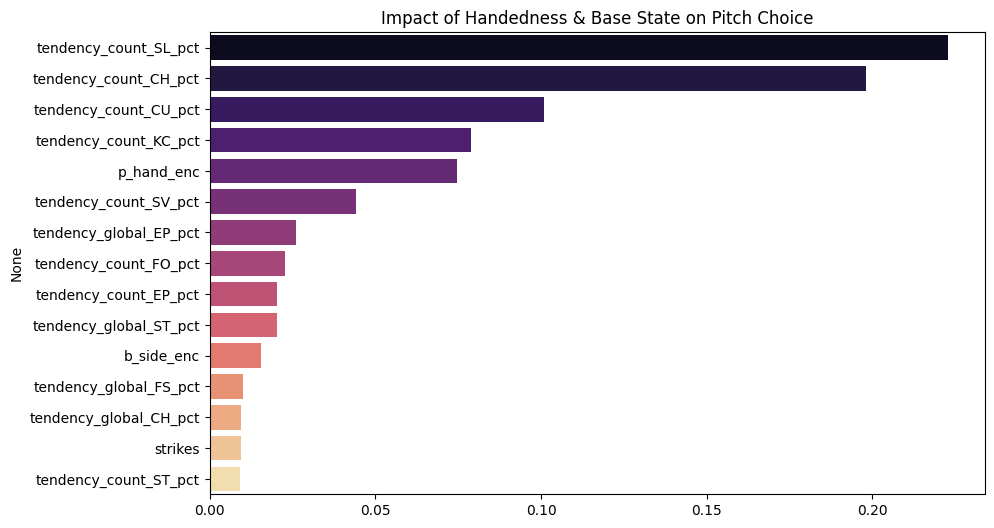

In [5]:
feat_imp = pd.Series(model.feature_importances_, index=X_cols).sort_values(ascending=False).head(15)
plt.figure(figsize=(10, 6))
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette="magma")
plt.title("Impact of Handedness & Base State on Pitch Choice")
plt.show()